In [1]:
%pip install schemdraw


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


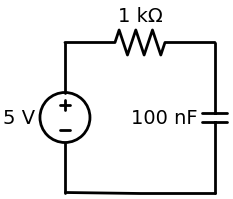

In [1]:
import schemdraw

import schemdraw.elements as elm

with schemdraw.Drawing(file="rc_filter.svg") as d:

    d += elm.SourceV().up().label("5 V")

    d += elm.Resistor().right().label("1 kΩ")

    d += elm.Capacitor().down().label("100 nF")

    d += elm.Line().left()

    

In [2]:
#!/usr/bin/env python3

"""
Draw a proposed TMC2226 motor power interlock:

- IRF5210PBF P-channel MOSFET as +24 V high-side switch
- NPN transistor pulls the MOSFET gate down through a resistor
- Zener clamps Vgs
- Bulk capacitor, bleed resistor, optional TVS on switched VMOT rail
- One global EN_ALL circuit for all five TMC2226 ENN pins

Output:
    tmc2226_interlock.svg
"""

import schemdraw
import schemdraw.elements as elm


OUTFILE = "tmc2226_interlock.svg"


def xy(p):
    """Return a plain (x, y) tuple from a Schemdraw Point or tuple."""
    if hasattr(p, "x") and hasattr(p, "y"):
        return (p.x, p.y)
    return (p[0], p[1])


def wire(d, a, b, label=None, loc="top"):
    e = elm.Line().endpoints(a, b)
    if label:
        e = e.label(label, loc=loc)
    d.add(e)
    return e


def dot(d, p):
    d.add(elm.Dot().at(p))


def ground_from(d, p, lead=0.35):
    x, y = xy(p)
    g = (x, y - lead)
    wire(d, p, g)
    d.add(elm.Ground().at(g))
    return g


def label(d, text, pos):
    d.add(elm.Label(text).at(pos))


# IEC box resistors look more natural for CH/EU schematics.
try:
    elm.style(elm.STYLE_IEC)
except AttributeError:
    pass


with schemdraw.Drawing(file=OUTFILE, show=False) as d:
    d.config(unit=2.0, inches_per_unit=0.42, fontsize=9)

    label(d, "24 V motor power switch, default OFF", (0.0, 9.6))

    # -------------------------------------------------------------------------
    # +24 V input, fuse, P-channel MOSFET high-side switch
    # -------------------------------------------------------------------------

    p24_in = (0.0, 8.0)
    p24_after_fuse = (2.2, 8.0)

    label(d, "+24V_IN", (-0.8, 8.35))

    d.add(
        elm.Fuse()
        .endpoints(p24_in, p24_after_fuse)
        .label("F1\nmotor rail fuse", loc="top")
    )

    q1 = d.add(
        elm.PMos(diode=True)
        .anchor("source")
        .at((4.1, 8.0))
        .label("Q1\nIRF5210PBF\nP-channel", loc="right")
    )

    wire(d, p24_after_fuse, q1.source)
    dot(d, q1.source)

    sx, sy = xy(q1.source)
    gx, gy = xy(q1.gate)
    dx, dy = xy(q1.drain)

    # Gate-source pull-up: default OFF.
    # When Q2 is off, gate rises to source, Vgs ~= 0 V.
    r1_top = (gx, sy)
    wire(d, q1.source, r1_top)

    d.add(
        elm.ResistorIEC()
        .endpoints(r1_top, q1.gate)
        .label("R1\n100k\nOFF pull-up", loc="right")
    )
    dot(d, q1.gate)

    # Gate-source zener clamp.
    # Electrical intention: cathode to source, anode to gate.
    z_top = (gx - 1.25, sy)
    z_bot = (gx - 1.25, gy)

    wire(d, r1_top, z_top)
    wire(d, q1.gate, z_bot)

    d.add(
        elm.Zener()
        .endpoints(z_bot, z_top)
        .label("D1\n10-12 V zener\ncathode to source", loc="left")
    )

    # -------------------------------------------------------------------------
    # NPN gate driver for Q1
    # -------------------------------------------------------------------------

    q2_collector_pos = (gx, gy - 1.4)

    q2 = d.add(
        elm.BjtNpn(circle=True)
        .anchor("collector")
        .at(q2_collector_pos)
        .label("Q2\nNPN\nBC547 / 2N2222", loc="right")
    )

    d.add(
        elm.ResistorIEC()
        .endpoints(q1.gate, q2.collector)
        .label("R2\n10k\ngate pull-down limit", loc="right")
    )

    ground_from(d, q2.emitter)

    bx, by = xy(q2.base)
    motor_power_gpio = (bx - 2.9, by)

    label(d, "MOTOR_POWER_GPIO\n3.3 V = VMOT ON", (motor_power_gpio[0] - 0.3, by + 0.55))

    d.add(
        elm.ResistorIEC()
        .endpoints(motor_power_gpio, q2.base)
        .label("R3\n4.7k", loc="bottom")
    )
    dot(d, q2.base)

    # Base pulldown: default Q2 off, therefore Q1 off.
    q2_base_pd_top = (bx - 0.45, by)
    q2_base_pd_bot = (bx - 0.45, by - 1.45)

    wire(d, q2_base_pd_top, q2.base)

    d.add(
        elm.ResistorIEC()
        .endpoints(q2_base_pd_top, q2_base_pd_bot)
        .label("R4\n100k", loc="left")
    )
    d.add(elm.Ground().at(q2_base_pd_bot))

    # -------------------------------------------------------------------------
    # Switched VMOT rail and protection / storage
    # -------------------------------------------------------------------------

    vmot_bus_1 = (dx + 2.0, dy)
    vmot_bus_2 = (dx + 5.8, dy)

    wire(d, q1.drain, vmot_bus_2, label="VMOT_SW", loc="top")
    dot(d, q1.drain)

    # Bulk capacitor on the switched rail.
    cap_top = vmot_bus_1
    cap_bot = (vmot_bus_1[0], dy - 2.0)

    dot(d, cap_top)

    d.add(
        elm.Capacitor(polar=True)
        .endpoints(cap_top, cap_bot)
        .label("Cbulk\n470-1000 µF\n35/50 V", loc="right")
    )
    d.add(elm.Ground().at(cap_bot))

    # Bleed resistor to discharge VMOT_SW after power-off.
    bleed_top = (vmot_bus_1[0] + 1.35, dy)
    bleed_bot = (bleed_top[0], dy - 2.0)

    dot(d, bleed_top)

    d.add(
        elm.ResistorIEC()
        .endpoints(bleed_top, bleed_bot)
        .label("Rbleed\n10k-47k", loc="right")
    )
    d.add(elm.Ground().at(bleed_bot))

    # Optional TVS / clamp. Pick the real part carefully.
    tvs_top = (vmot_bus_1[0] + 2.8, dy)
    tvs_bot = (tvs_top[0], dy - 2.0)

    dot(d, tvs_top)

    d.add(
        elm.Zener()
        .endpoints(tvs_bot, tvs_top)
        .label("optional TVS\ncheck standoff\nvoltage", loc="right")
    )
    d.add(elm.Ground().at(tvs_bot))

    # -------------------------------------------------------------------------
    # Driver block: 5 TMC2226 carrier modules
    # -------------------------------------------------------------------------

    drivers = d.add(
        elm.Ic()
        .side("L", spacing=0.75, pad=1.0, leadlen=0.7)
        .side("R", spacing=0.75, pad=1.0, leadlen=0.7)
        .side("B", spacing=0.75, pad=0.8, leadlen=0.6)
        .pin(name="VMOT", side="left")
        .pin(name="VIO", side="left")
        .pin(name="ENN", side="left")
        .pin(name="GND", side="bottom")
        .pin(name="LOGIC", side="right")
        .pin(name="MOTORS", side="right")
        .label("5 × TMC2226\nmodules")
        .anchor("VMOT")
        .at((12.0, dy))
    )

    wire(d, vmot_bus_2, drivers.VMOT)
    d.add(elm.Ground().at(drivers.GND))

    logic_x, logic_y = xy(drivers.LOGIC)
    motors_x, motors_y = xy(drivers.MOTORS)

    wire(d, drivers.LOGIC, (logic_x + 1.6, logic_y), label="STEP / DIR / UART\nfrom Pico", loc="right")
    wire(d, drivers.MOTORS, (motors_x + 1.6, motors_y), label="to motors", loc="right")

    # -------------------------------------------------------------------------
    # VIO and global EN_ALL circuit
    # -------------------------------------------------------------------------

    label(d, "One global EN_ALL circuit, default DISABLED", (6.0, 2.7))

    vio_x, vio_y = xy(drivers.VIO)
    enn_x, enn_y = xy(drivers.ENN)

    vio_left = (vio_x - 4.5, vio_y)
    vio_pullup_top = (enn_x - 2.15, vio_y)
    en_all_node = (enn_x - 2.15, enn_y)

    wire(d, vio_left, drivers.VIO, label="+3V3_LOGIC / VIO", loc="top")
    dot(d, vio_pullup_top)

    d.add(
        elm.ResistorIEC()
        .endpoints(vio_pullup_top, en_all_node)
        .label("R5\n10k\nENN high = disabled", loc="right")
    )

    wire(d, en_all_node, drivers.ENN, label="EN_ALL", loc="top")
    dot(d, en_all_node)

    # NPN pulls ENN low only when firmware explicitly enables motors.
    q3 = d.add(
        elm.BjtNpn(circle=True)
        .anchor("collector")
        .at((en_all_node[0], en_all_node[1] - 1.15))
        .label("Q3\nNPN\nEN pull-down", loc="right")
    )

    wire(d, en_all_node, q3.collector)
    ground_from(d, q3.emitter)

    q3_bx, q3_by = xy(q3.base)
    enable_gpio = (q3_bx - 2.4, q3_by)

    label(d, "ENABLE_GPIO\n3.3 V = drivers enabled", (enable_gpio[0] - 0.4, q3_by + 0.55))

    d.add(
        elm.ResistorIEC()
        .endpoints(enable_gpio, q3.base)
        .label("R6\n4.7k", loc="bottom")
    )
    dot(d, q3.base)

    q3_base_pd_top = (q3_bx - 0.45, q3_by)
    q3_base_pd_bot = (q3_bx - 0.45, q3_by - 1.35)

    wire(d, q3_base_pd_top, q3.base)

    d.add(
        elm.ResistorIEC()
        .endpoints(q3_base_pd_top, q3_base_pd_bot)
        .label("R7\n100k", loc="left")
    )
    d.add(elm.Ground().at(q3_base_pd_bot))

    # -------------------------------------------------------------------------
    # Sequencing note
    # -------------------------------------------------------------------------

    label(
        d,
        "Suggested startup: GPIOs low/floating -> VMOT off and ENN high. "
        "Then switch VMOT on, configure drivers, finally assert ENABLE_GPIO.",
        (0.0, -2.5),
    )


print(f"Wrote {OUTFILE}")

Wrote tmc2226_interlock.svg


In [3]:
import schemdraw
import schemdraw.elements as elm

OUT = "motor_high_side_switch.svg"

with schemdraw.Drawing(file=OUT, show=False) as d:
    d.config(unit=2.2, inches_per_unit=0.55, fontsize=11)

    # Main power path
    d += elm.Dot().label("+24V_IN", loc="left")
    d += elm.Fuse().right().label("F1\nfuse")
    d += elm.Line().right()

    q1 = d.add(
        elm.PMos(diode=True)
        .anchor("source")
        .label("Q1\nIRF5210PBF\nP-MOSFET", loc="right")
    )

    d += elm.Line().at(q1.drain).right().length(2.0)
    d += elm.Dot().label("VMOT_SW\n+24V to drivers", loc="right")

    # Gate pull-up: default OFF
    d += elm.Resistor().at(q1.source).down().toy(q1.gate).label("R1\n100k\nOFF pull-up")
    d += elm.Line().to(q1.gate)

    # Zener clamp from gate to source
    d += elm.Line().at(q1.source).left().length(1.4)
    ztop = d.here
    d += elm.Zener().down().toy(q1.gate).label("D1\n10V or 12V\nVgs clamp", loc="left")
    d += elm.Line().right().tox(q1.gate)

    # NPN pulls P-MOS gate down when GPIO is high
    d += elm.Resistor().at(q1.gate).down().length(1.2).label("R2\n10k")
    q2 = d.add(
        elm.BjtNpn(circle=True)
        .anchor("collector")
        .label("Q2\nNPN\nBC547 / 2N2222", loc="right")
    )

    d += elm.Line().at(q2.emitter).down().length(0.4)
    d += elm.Ground()

    # GPIO drive into NPN base
    d += elm.Resistor().at(q2.base).left().length(1.7).label("R3\n4.7k")
    d += elm.Dot().label("MOTOR_POWER_GPIO\n3.3V = ON", loc="left")

    # Base pulldown: default OFF
    d += elm.Line().at(q2.base).down().length(0.8)
    d += elm.Resistor().down().length(1.0).label("R4\n100k")
    d += elm.Ground()

print(f"Wrote {OUT}")

Wrote motor_high_side_switch.svg


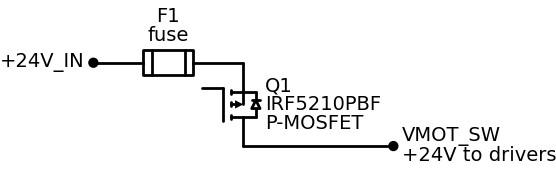

In [4]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing(file="01_power_path.svg") as d:
    d += elm.Dot().label("+24V_IN", loc="left")

    d += elm.Fuse().right().label("F1\nfuse")

    q1 = d.add(
        elm.PMos(diode=True)
        .right()
        .label("Q1\nIRF5210PBF\nP-MOSFET")
    )

    d += elm.Line().right()
    d += elm.Dot().label("VMOT_SW\n+24V to drivers", loc="right")

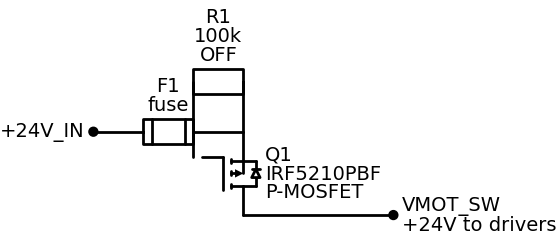

In [5]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing(file="02_power_path_gate_pullup.svg") as d:
    d += elm.Dot().label("+24V_IN", loc="left")

    d += elm.Fuse().right().label("F1\nfuse")

    q1 = d.add(
        elm.PMos(diode=True)
        .right()
        .label("Q1\nIRF5210PBF\nP-MOSFET")
    )

    d += elm.Line().right()
    d += elm.Dot().label("VMOT_SW\n+24V to drivers", loc="right")

    # Gate pull-up: default OFF
    d += elm.Line().at(q1.source).up().length(1.0)
    d += elm.Resistor().left().tox(q1.gate).label("R1\n100k\nOFF")
    d += elm.Line().down().to(q1.gate)

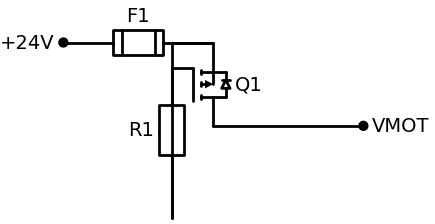

In [7]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing(file="02_power_path_gate_pullup.svg") as d:

    d += elm.Dot().label("+24V", loc="left")

    d += elm.Fuse().right().label("F1")

    q1 = d.add(
        elm.PMos(diode=True)
        .right()
        .label("Q1")
    )

    d += elm.Line().right()
    d += elm.Dot().label("VMOT", loc="right")

    #
    # Gate pull-up resistor
    #

    d += elm.Line().at(q1.gate).down()

    d += elm.Resistor().up().toy(q1.source).label("R1")

    d += elm.Line().to(q1.source)

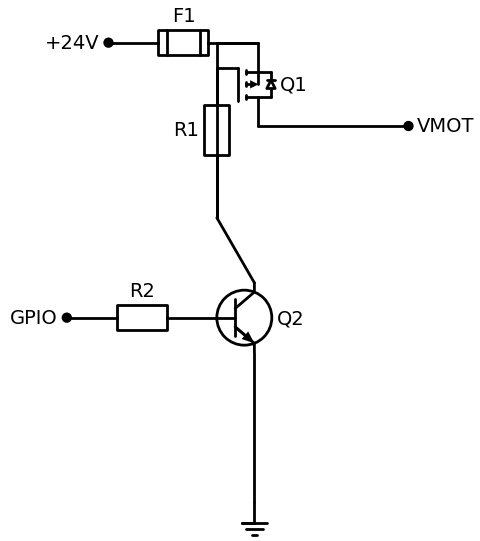

In [13]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing(file="03_high_side_switch.svg") as d:

    #
    # Main power path
    #

    d += elm.Dot().label("+24V", loc="left")

    d += elm.Fuse().right().label("F1")

    q1 = d.add(
        elm.PMos(diode=True)
        .right()
        .label("Q1")
    )

    d += elm.Line().right()
    d += elm.Dot().label("VMOT", loc="right")

    #
    # R1 pulls gate to source -> default OFF
    #

    d += elm.Line().at(q1.gate).down()

    gate_node = d.here

    d += elm.Resistor().up().toy(q1.source).label("R1")

    d += elm.Line().to(q1.source)

    #
    # NPN transistor pulls gate down
    #

    q2 = d.add(

        elm.BjtNpn(circle=True)

        .at((gate_node.x, gate_node.y - 2))

        .label("Q2")

    )

    # collector to gate node

    d += elm.Line().at(q2.collector).to(gate_node)

    # emitter to ground

    d += elm.Line().at(q2.emitter).down()

    d += elm.Ground()

    #

    # GPIO drives Q2 base

    #

    d += elm.Resistor().at(q2.base).left().label("R2")

    d += elm.Dot().label("GPIO", loc="left")

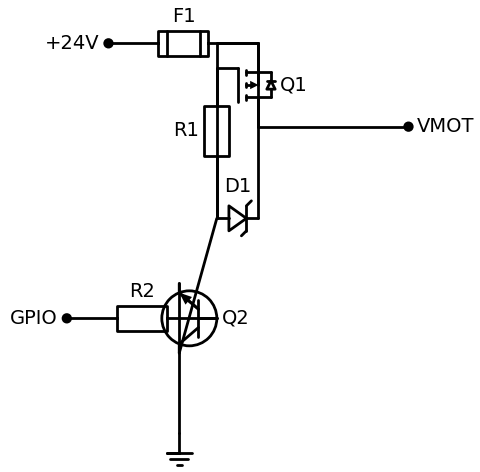

In [12]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing(file="04_high_side_switch_with_zener.svg") as d:

    #
    # Main power path
    #

    d += elm.Dot().label("+24V", loc="left")

    d += elm.Fuse().right().label("F1")

    q1 = d.add(
        elm.PMos(diode=True)
        .right()
        .label("Q1")
    )

    d += elm.Line().right()
    d += elm.Dot().label("VMOT", loc="right")

    #
    # Gate node
    #

    d += elm.Line().at(q1.gate).down()
    gate_node = d.here

    #
    # R1 pulls gate to source -> default OFF
    #

    d += elm.Resistor().up().toy(q1.source).label("R1")
    d += elm.Line().to(q1.source)

    #
    # D1 clamps gate-source voltage
    # Cathode to source, anode to gate
    #

    d += elm.Zener().at(gate_node).right().tox(q1.source).label("D1")
    d += elm.Line().up().toy(q1.source)
    d += elm.Line().left().to(q1.source)

    #
    # Q2 pulls gate down when GPIO is high
    #

    q2 = d.add(
        elm.BjtNpn(circle=True)
        .at((gate_node.x, gate_node.y - 2))
        .label("Q2")
    )

    d += elm.Line().at(q2.collector).to(gate_node)

    d += elm.Line().at(q2.emitter).down()
    d += elm.Ground()

    #
    # GPIO drives Q2 base
    #

    d += elm.Resistor().at(q2.base).left().label("R2")
    d += elm.Dot().label("GPIO", loc="left")

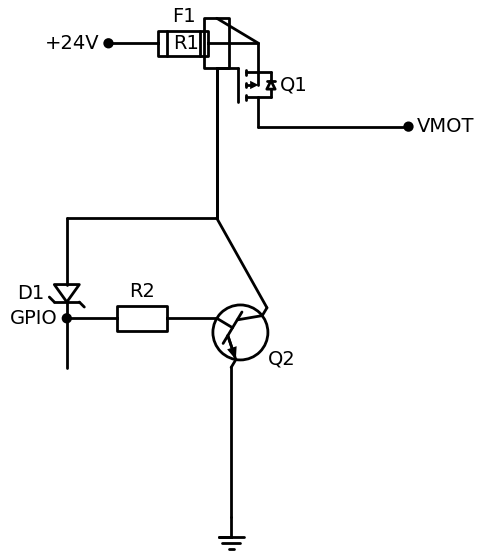

In [14]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing(file="04_high_side_switch_zener_dangling.svg") as d:

    #
    # Main power path
    #

    d += elm.Dot().label("+24V", loc="left")

    d += elm.Fuse().right().label("F1")

    q1 = d.add(
        elm.PMos(diode=True)
        .right()
        .label("Q1")
    )

    d += elm.Line().right()
    d += elm.Dot().label("VMOT", loc="right")

    #
    # Gate node
    #

    d += elm.Line().at(q1.gate).down()

    gate_node = d.here

    #
    # D1 branch from gate node: first left, then down.
    # Left dangling for now.
    #

    d += elm.Line().at(gate_node).left()

    d += elm.Zener().down().label("D1")

    #
    # R1 pulls gate to source -> default OFF
    #

    d += elm.Line().at(gate_node).up()

    d += elm.Resistor().up().toy(q1.source).label("R1")

    d += elm.Line().to(q1.source)

    #
    # NPN transistor pulls gate down
    #

    q2 = d.add(
        elm.BjtNpn(circle=True)
        .at((gate_node.x, gate_node.y - 2))
        .label("Q2")
    )

    # collector to gate node

    d += elm.Line().at(q2.collector).to(gate_node)

    # emitter to ground

    d += elm.Line().at(q2.emitter).down()

    d += elm.Ground()

    #
    # GPIO drives Q2 base
    #

    d += elm.Resistor().at(q2.base).left().label("R2")

    d += elm.Dot().label("GPIO", loc="left")

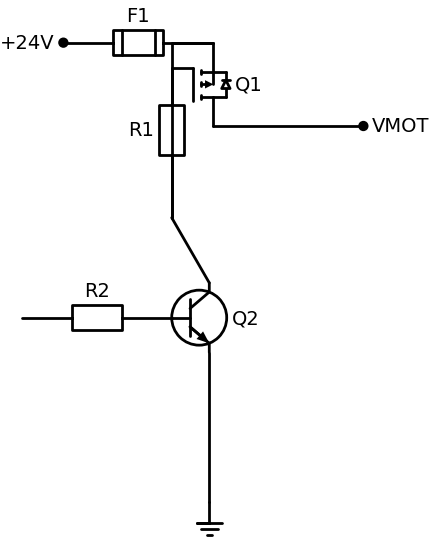

In [23]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing(file="03_high_side_switch.svg") as d:

    #
    # Main power path
    #

    d += elm.Dot().label("+24V", loc="left")

    d += elm.Fuse().right().label("F1")

    q1 = d.add(
        elm.PMos(diode=True)
        .right()
        .label("Q1")
    )



    d += elm.Line().right()
    d += elm.Dot().label("VMOT", loc="right")

    #
    # R1 pulls gate to source -> default OFF
    #

    d += elm.Line().at(q1.gate).down()

    gate_node = d.here

    d += elm.Resistor().up().toy(q1.source).label("R1")

    d += elm.Line().to(q1.source)

    #
    # NPN transistor pulls gate down
    #

    q2 = d.add(

        elm.BjtNpn(circle=True)

        .at((gate_node.x, gate_node.y - 2))

        .label("Q2")

    )

    # collector to gate node

    d += elm.Line().at(q2.collector).to(gate_node)

    # emitter to ground

    d += elm.Line().at(q2.emitter).down()

    d += elm.Ground()

    #


    d += elm.Resistor().at(q2.base).left().label("R2")

    # d += elm.Dot().label("GPIO", loc="left")


    # d += elm.Dot().at(q1.gate)

    # d += elm.Line().at(q1.gate).left()

    # d += elm.Zener().down().label("D1")



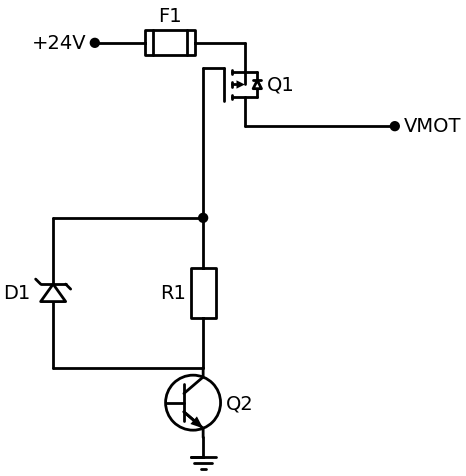

In [71]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing(file="03_high_side_switch.svg") as d:

    #
    # Main power path
    #

    d += elm.Dot().label("+24V", loc="left")

    d += elm.Fuse().right().label("F1")

    q1 = d.add(
        elm.PMos(diode=True)
        .right()
        .label("Q1")
    )

    d += elm.Line().right()
    d += elm.Dot().label("VMOT", loc="right")

    #
    # R1 pulls gate to source -> default OFF
    #

    d += elm.Line().at(q1.gate).down()

    gate_node = d.here
    d += elm.Dot().at(gate_node)

    d += elm.Resistor().at(gate_node).down().label("R1")
    with d.hold():
        d += elm.Line().left()


        d += elm.Zener().up().label("D1")
        d += elm.Line().right().to(gate_node)

    q2 = elm.BjtNpn(circle=True).right().anchor("collector").label("Q2")
    d += elm.Ground().at(q2.emitter)


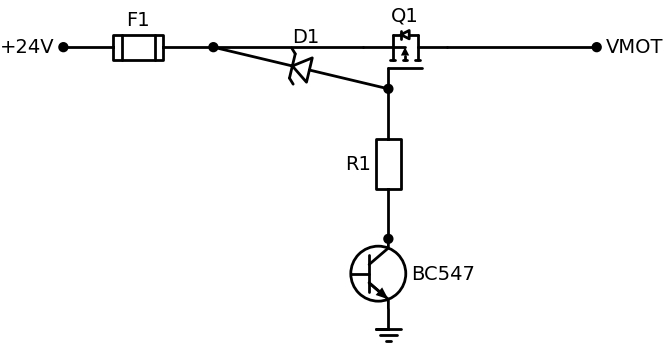

In [121]:
import schemdraw
import schemdraw.elements as elm

gate_node = None

with schemdraw.Drawing(file="03_high_side_switch.svg") as d:

    #
    # Main power path
    #

    elm.Dot().label("+24V", loc="left")

    elm.Fuse().right().label("F1")

    after_fuse = elm.Dot()
    
    elm.Line().right()

    q1 = d.add(elm.PMos(diode=True).theta(90).label("Q1"))


    gate_node = elm.Dot().at(q1.gate)

    
    elm.Line().at(q1.drain).right()
    elm.Dot().label("VMOT", loc="right")

    elm.Resistor().at(q1.gate).down().label("R1")
    r1_end = elm.Dot()
    q2 = elm.BjtNpn(circle=True).right().anchor("collector").label("BC547")
    elm.Ground().at(q2.emitter)


    elm.Zener().at(after_fuse.start).to(gate_node.start).reverse().label("D1")
        
        

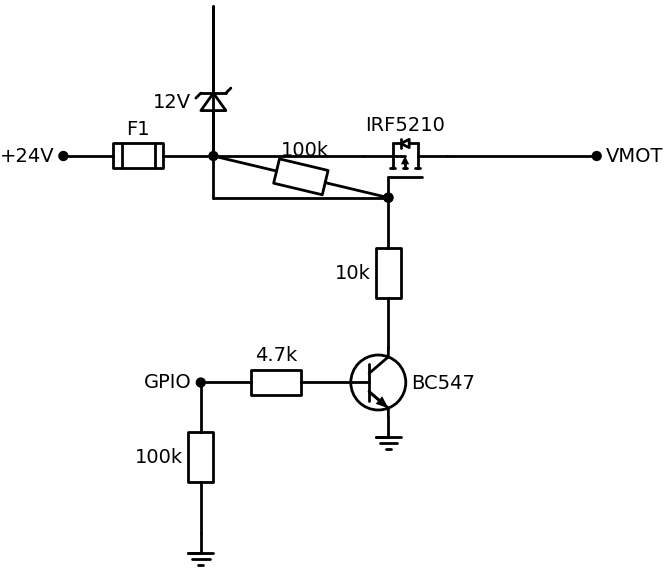

In [122]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing(file="05_high_side_switch_complete.svg") as d:

    #
    # Main power path
    #

    elm.Dot().label("+24V", loc="left")

    elm.Fuse().right().label("F1")

    after_fuse = elm.Dot()

    elm.Line().right()

    q1 = (
        elm.PMos(diode=True)
        .theta(90)
        .label("IRF5210")
    )

    elm.Line().at(q1.drain).right()

    elm.Dot().label("VMOT", loc="right")

    #
    # Gate node
    #

    gate_node = elm.Dot().at(q1.gate)

    #
    # 100k gate-source pull-up.
    # This keeps the P-MOSFET off by default.
    #

    elm.Resistor().at(after_fuse.start).to(gate_node.start).label("100k")

    #
    # 12V zener gate-source clamp.
    #
    # Cathode must be on after_fuse / Q1 source.
    # Anode must be on Q1 gate.
    #

    elm.Line().at(after_fuse.start).up()

    elm.Zener().reverse().down().toy(gate_node.start).label("12V")

    elm.Line().to(gate_node.start)

    elm.Dot().at(gate_node.start)

    #
    # 10k gate pull-down / zener current limiter
    #

    elm.Resistor().at(gate_node.start).down().label("10k")

    #
    # NPN pulls gate down when GPIO is high
    #

    q2 = (
        elm.BjtNpn(circle=True)
        .right()
        .anchor("collector")
        .label("BC547")
    )

    elm.Ground().at(q2.emitter)

    #
    # GPIO drives Q2 base
    #

    elm.Resistor().at(q2.base).left().label("4.7k")

    gpio_node = elm.Dot().label("GPIO", loc="left")

    #
    # GPIO pulldown: Q2 off if GPIO floats
    #

    elm.Resistor().at(gpio_node.start).down().label("100k")

    elm.Ground()

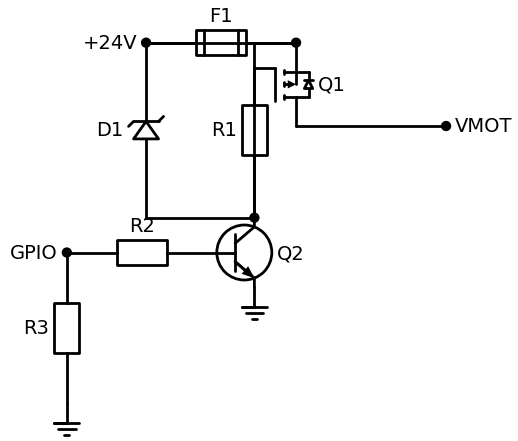

In [58]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing(file="04_high_side_switch_complete.svg") as d:

    #
    # Main power path
    #

    elm.Dot().label("+24V", loc="left")

    elm.Fuse().right().label("F1")

    q1 = d.add(
        elm.PMos(diode=True)
        .right()
        .label("Q1")
    )

    elm.Line().right()
    elm.Dot().label("VMOT", loc="right")

    #
    # Gate node of Q1
    #

    elm.Line().at(q1.gate).down()

    gate_node = d.here
    elm.Dot().at(gate_node)

    #
    # R1 pulls Q1 gate to Q1 source -> default OFF
    #

    with d.hold():
        elm.Resistor().at(gate_node).up().toy(q1.source).label("R1")
        elm.Line().to(q1.source)
        elm.Dot().at(q1.source)

    #
    # D1 clamps Q1 gate-source voltage.
    #
    # Important:
    # D1 cathode goes to Q1 source / +24V side.
    # D1 anode goes to Q1 gate.
    #
    # With this drawing direction, reverse().down() puts the zener
    # cathode at the top.
    #

    with d.hold():
        elm.Line().at(q1.source).left()
        elm.Zener().reverse().down().toy(gate_node).label("D1")
        elm.Line().right().to(gate_node)

    #
    # Q2 pulls Q1 gate down when GPIO is high
    #

    q2 = d.add(
        elm.BjtNpn(circle=True)
        .right()
        .anchor("collector")
        .label("Q2")
    )

    elm.Ground().at(q2.emitter)

    #
    # GPIO drives Q2 base
    #

    elm.Resistor().at(q2.base).left().label("R2")

    gpio_node = d.here
    elm.Dot().label("GPIO", loc="left")

    #
    # R3 keeps Q2 off if GPIO is floating
    #

    with d.hold():
        elm.Resistor().at(gpio_node).down().label("R3")
        elm.Ground()

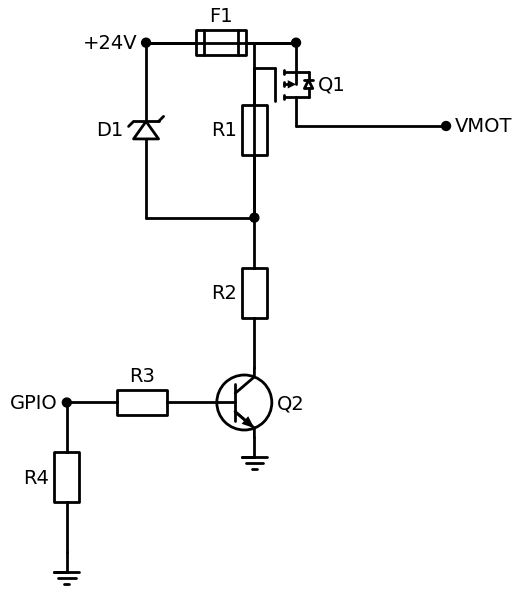

In [59]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing(file="04_high_side_switch_complete.svg") as d:

    #
    # Main power path
    #

    elm.Dot().label("+24V", loc="left")

    elm.Fuse().right().label("F1")

    q1 = (
        elm.PMos(diode=True)
        .right()
        .label("Q1")
    )

    elm.Line().right()
    elm.Dot().label("VMOT", loc="right")

    #
    # Gate node of Q1
    #

    elm.Line().at(q1.gate).down()

    gate_node = d.here
    elm.Dot().at(gate_node)

    #
    # R1 pulls Q1 gate to Q1 source -> default OFF
    #

    with d.hold():
        elm.Resistor().at(gate_node).up().toy(q1.source).label("R1")
        elm.Line().to(q1.source)
        elm.Dot().at(q1.source)

    #
    # D1 clamps Q1 gate-source voltage.
    #
    # D1 is in parallel with R1:
    #   cathode -> Q1 source, after F1
    #   anode   -> Q1 gate
    #

    with d.hold():
        elm.Line().at(q1.source).left()
        elm.Zener().reverse().down().toy(gate_node).label("D1")
        elm.Line().right().to(gate_node)

    #
    # R2 limits gate pull-down and zener current
    #

    elm.Resistor().at(gate_node).down().label("R2")

    #
    # Q2 pulls Q1 gate down through R2 when GPIO is high
    #

    q2 = (
        elm.BjtNpn(circle=True)
        .right()
        .anchor("collector")
        .label("Q2")
    )

    elm.Ground().at(q2.emitter)

    #
    # GPIO drives Q2 base
    #

    elm.Resistor().at(q2.base).left().label("R3")

    gpio_node = d.here
    elm.Dot().label("GPIO", loc="left")

    #
    # R4 keeps Q2 off if GPIO is floating
    #

    with d.hold():
        elm.Resistor().at(gpio_node).down().label("R4")
        elm.Ground()

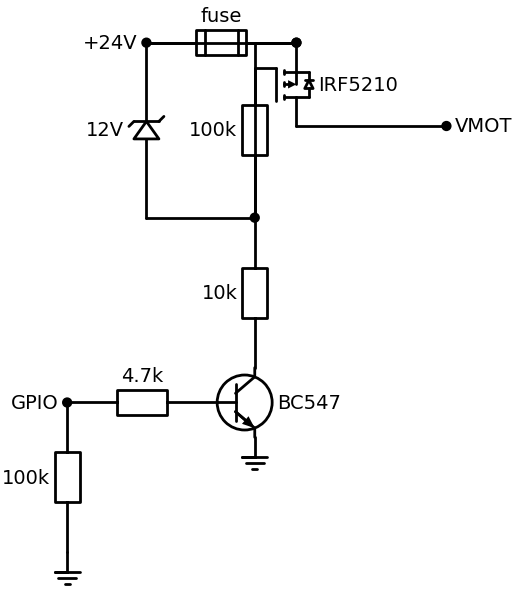

In [62]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing(file="04_high_side_switch_complete_values.svg") as d:

    #
    # Main power path
    #

    elm.Dot().label("+24V", loc="left")

    elm.Fuse().right().label("fuse")

    after_fuse = elm.Dot()

    q1 = (
        elm.PMos(diode=True)
        .right()
        .anchor("source")
        .label("IRF5210")
    )

    elm.Line().right()
    elm.Dot().label("VMOT", loc="right")

    #
    # Gate node of Q1
    #

    elm.Line().at(q1.gate).down()

    gate_node = d.here
    elm.Dot().at(gate_node)

    #
    # Gate-source pull-up:
    # pulls gate to source -> P-MOSFET OFF by default
    #

    with d.hold():
        elm.Resistor().at(gate_node).up().toy(q1.source).label("100k")
        elm.Line().to(q1.source)
        elm.Dot().at(q1.source)

    #
    # Zener clamp:
    # cathode to source, anode to gate
    #

    with d.hold():
        elm.Line().at(q1.source).left()
        elm.Zener().reverse().down().toy(gate_node).label("12V")
        elm.Line().right().to(gate_node)

    #
    # Gate pull-down resistor:
    # limits zener current when the NPN is on
    #

    elm.Resistor().at(gate_node).down().label("10k")

    #
    # NPN pulls gate down when GPIO is high
    #

    q2 = (
        elm.BjtNpn(circle=True)
        .right()
        .anchor("collector")
        .label("BC547")
    )

    elm.Ground().at(q2.emitter)

    #
    # GPIO drives Q2 base
    #

    elm.Resistor().at(q2.base).left().label("4.7k")

    gpio_node = d.here
    elm.Dot().label("GPIO", loc="left")

    #
    # Base pulldown:
    # keeps Q2 off if GPIO is floating
    #

    with d.hold():
        elm.Resistor().at(gpio_node).down().label("100k")
        elm.Ground()

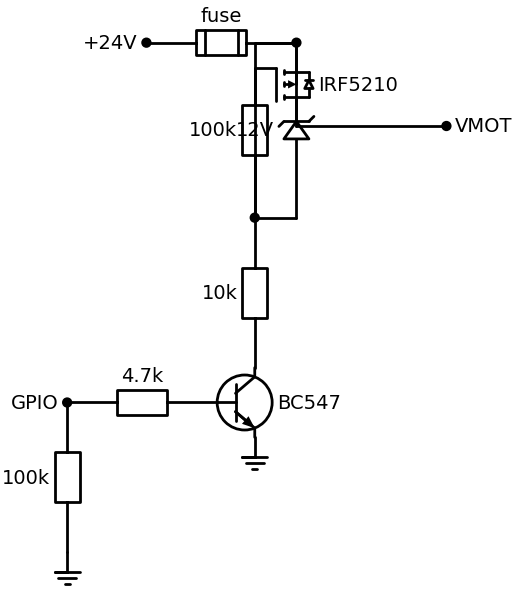

In [67]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing(file="04_high_side_switch_complete_values.svg") as d:

    #
    # Main power path
    #

    elm.Dot().label("+24V", loc="left")

    elm.Fuse().right().label("fuse")

    q1 = (
        elm.PMos(diode=True)
        .right()
        .label("IRF5210")
    )

    elm.Line().right()
    elm.Dot().label("VMOT", loc="right")

    #
    # Gate node of Q1
    #

    elm.Line().at(q1.gate).down()
    gate_node = d.here
    elm.Dot().at(gate_node)

    #
    # 100k pulls Q1 gate to Q1 source -> default OFF
    #

    with d.hold():
        elm.Resistor().at(gate_node).up().toy(q1.source).label("100k")
        elm.Line().to(q1.source)
        elm.Dot().at(q1.source)

    #
    # 12V zener clamps Q1 Vgs.
    #
    # It is connected between Q1 source and Q1 gate,
    # in parallel with the 100k.
    #
    # Cathode: Q1 source, after fuse
    # Anode:   Q1 gate
    #

    with d.hold():
        elm.Zener().reverse().at(q1.source).down().toy(gate_node).label("12V")
        elm.Line().to(gate_node)

    #
    # 10k limits gate pull-down and zener current
    #

    elm.Resistor().at(gate_node).down().label("10k")

    #
    # BC547 pulls Q1 gate down through 10k when GPIO is high
    #

    q2 = (
        elm.BjtNpn(circle=True)
        .right()
        .anchor("collector")
        .label("BC547")
    )

    elm.Ground().at(q2.emitter)

    #
    # GPIO drives Q2 base
    #

    elm.Resistor().at(q2.base).left().label("4.7k")

    gpio_node = d.here
    elm.Dot().label("GPIO", loc="left")

    #
    # 100k keeps Q2 off if GPIO is floating
    #

    with d.hold():
        elm.Resistor().at(gpio_node).down().label("100k")
        elm.Ground()